# DeepBlood: Применение современных архитектур объектной детекции для высокоточного анализа мазков крови

Линейка моделей **YOLO (You Only Look Once)** — одна из самых успешных и активно развивающихся серий методов для детекции объектов в реальном времени. На момент своего выхода **YOLOv3 (2018)** считалась **state-of-the-art** среди моделей реального времени, предлагая выдающийся баланс между скоростью и точностью и став де-факто стандартом для практических приложений. Спустя несколько лет эволюции, **YOLOv8 (2023)** вновь закрепила лидерство серии, став одной из **SOTA-моделей** своего времени: она отказалась от анкоров (anchor-free), получила новую модульную архитектуру и поддержку множества задач — от детекции и сегментации до классификации и оценки поз. 

**Актуальность**

* В контексте детекции клеток крови проект решает критическую проблему дифференциальной диагностики.

* Точный подсчет популяции: Соотношение лейкоцитов, эритроцитов и тромбоцитов является ключевым индикатором состояния иммунной системы и кроветворения.

* Выявление аномалий на ранних стадиях: Модели YOLO способны детектировать даже незначительные скопления тромбоцитов или изменения в структуре клеток, которые глаз человека может пропустить при массовом просмотре слайдов.

* Стандартизация: Нейросеть всегда применяет одинаковые критерии оценки, что устраняет вариативность диагнозов между разными лабораториями.

**Где это внедрять?** 

* Цифровая микроскопия: Создание программных модулей для микроскопов с камерами, которые в реальном времени подсвечивают и классифицируют клетки прямо во время осмотра препарата врачом.

* Мобильные диагностические комплексы: Развертывание легких моделей (YOLOv8-nano) на планшетах или смартфонах для использования в полевых госпиталях и экспресс-лабораториях.

* Облачные сервисы анализа: Загрузка отсканированных снимков на сервер для автоматической генерации предварительного отчета по формуле крови.

In [ ]:
import os, time, random, math
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
from torchmetrics.detection import MeanAveragePrecision
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from typing import Any, Tuple, List, Optional, Union, Callable
from typing import Callable
from torch.optim import Optimizer
from sklearn.cluster import KMeans
SEED = 1337
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Torch:", torch.__version__, "| Device:", device)

BATCH_SIZE = 8

Torch: 2.8.0+cu126 | Device: cuda


Данные: **Blood Cell Detection Dataset**

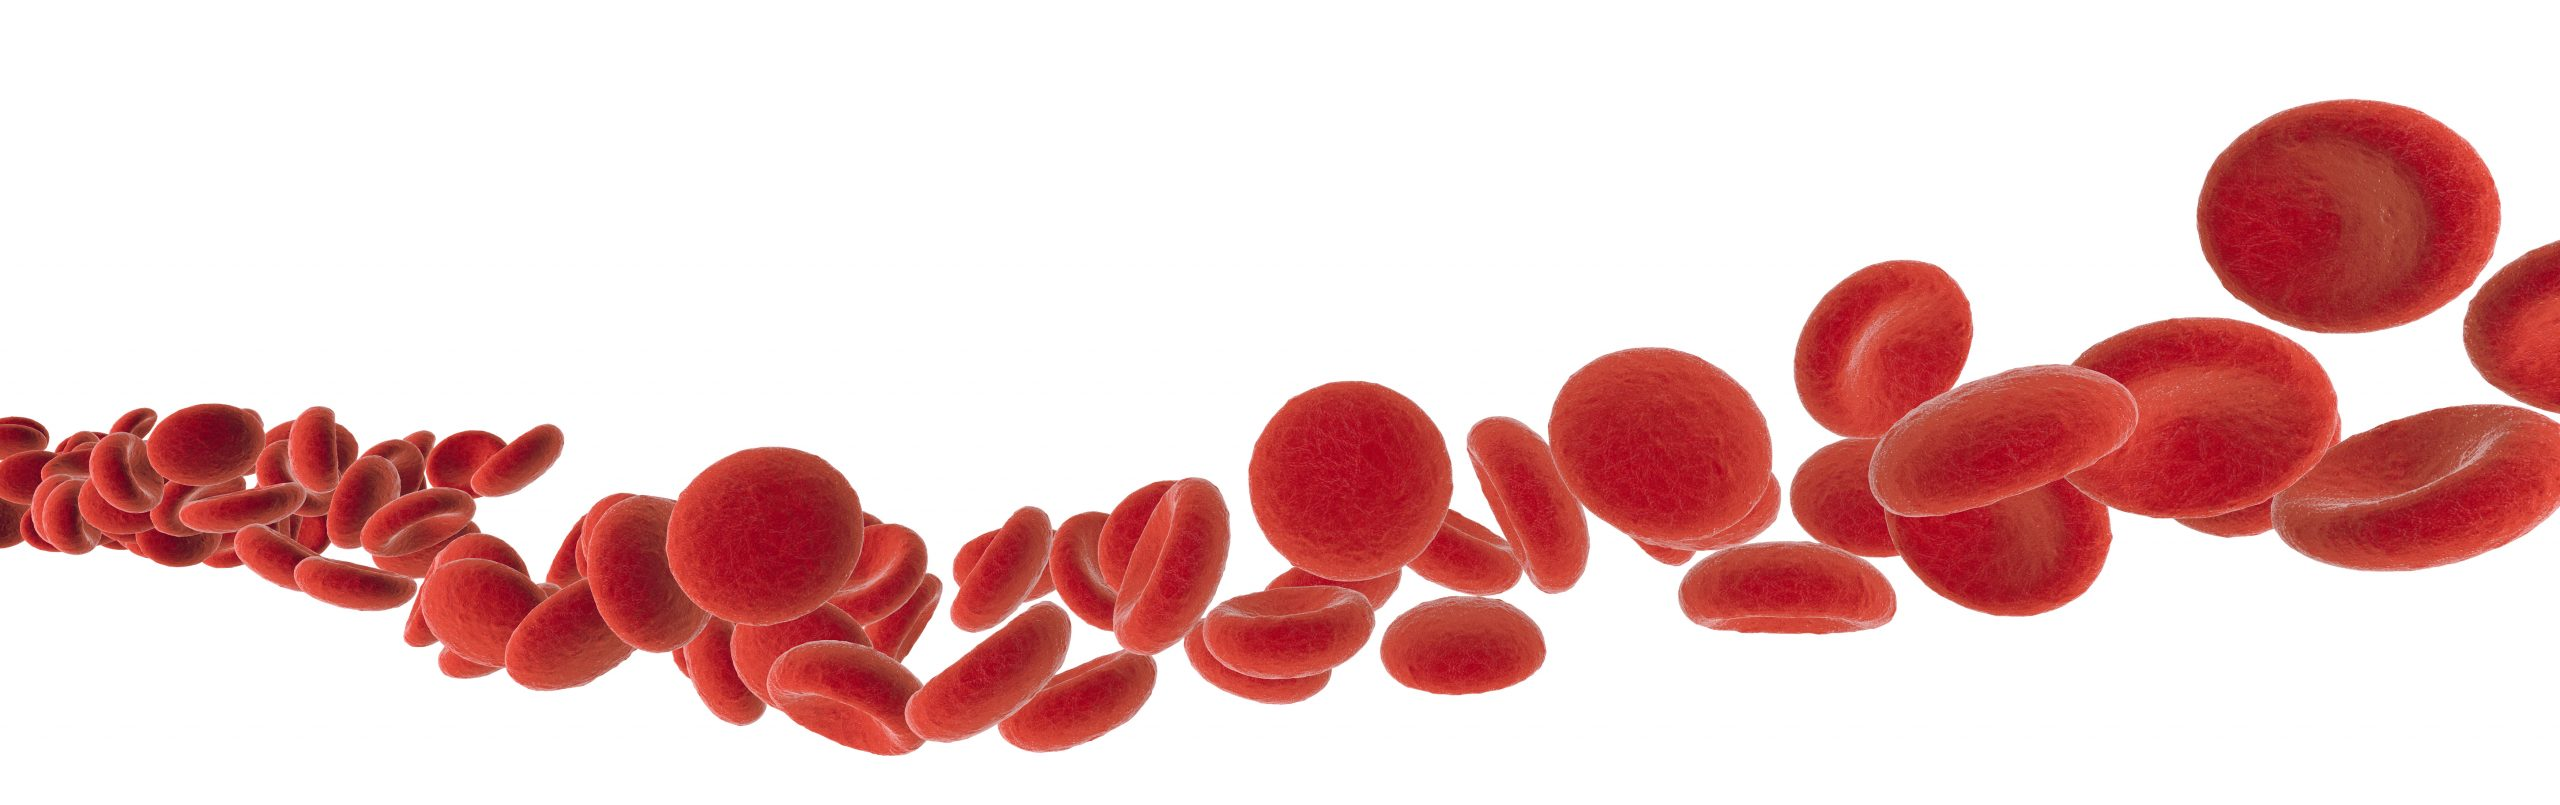

[Blood Cell Detection Dataset](https://www.kaggle.com/datasets/adhoppin/blood-cell-detection-datatset/data) — набор изображений мазков крови, предназначенный для обучения моделей детекции. Датасет содержит фотографии клеток крови с разметкой трёх классов: **эритроцитов (RBC)**, **лейкоцитов (WBC)** и **тромбоцитов (Platelets)**. Детекция клеток крови имеет важное практическое значение: она помогает автоматизировать анализ крови и выявлять патологии.

In [ ]:
class BloodCellDataset(Dataset):
    """
    PyTorch-датасет для BloodCell Detection Dataset в cx-cy-w-h формате.

    Ожидаемая структура:
        root_dir/
          train|valid|test/
            images/*.jpg
            labels/*.txt  (label cx cy w h, координаты нормализованы [0,1])

    Предполагается, что все изображения уже приведены к одному размеру (416×416).

    На выходе:
        image : Tensor (3, H, W)
        target: dict с полями
            "boxes"  — Tensor (N,4) в cxcxwh-формате,
            "labels" — Tensor (N,) с индексами классов,
            "path"   — путь до исходного файла.
    """

    def __init__(self, root_dir: str | Path, split: str = "train"):
        """Инициализирует датасет, находя пути ко всем изображениям.

        Args:
            root_dir (str | Path): Путь к корневой директории датасета.
            split (str, optional): Сплит данных ("train", "valid", "test").
                По умолчанию "train".
        """
        assert split in ["train", "valid", "test"]
        split_dir = Path(root_dir) / split
        self.img_dir = split_dir / "images"
        self.label_dir = split_dir / "labels"

        exts = {".jpg", ".jpeg", ".png"}
        self.img_paths = sorted([p for p in self.img_dir.rglob("*") if p.suffix.lower() in exts])

    def __len__(self) -> int:
        """Возвращает общее количество изображений в датасете."""
        return len(self.img_paths)

    def __getitem__(self, idx: int) -> tuple[torch.Tensor, dict]:
        """Загружает и возвращает один элемент датасета по индексу.

        Args:
            idx (int): Индекс запрашиваемого элемента.

        Returns:
            tuple[torch.Tensor, dict]: Кортеж (image, target), где:
                - image: тензор изображения (C, H, W).
                - target: словарь с аннотациями {"boxes", "labels", "path"}.
        """
        ip = self.img_paths[idx]
        lbl = self.label_dir / (ip.stem + ".txt")

        # Считываем изображение
        img = Image.open(ip).convert("RGB")

        # Считываем координаты боксов и классы
        boxes = []
        labels = []
        if lbl.exists():
            with open(lbl, "r") as f:
                for line in f.read().strip().splitlines():
                    vals = line.strip().split()
                    if len(vals) >= 5:
                        labels.append(int(float(vals[0])))
                        cx, cy, w, h = map(float, vals[1:5])
                        boxes.append([cx, cy, w, h])

        img_t = transforms.ToTensor()(img)
        boxes = torch.tensor(boxes, dtype=torch.float32)
        labels = torch.tensor(labels, dtype=torch.int64)

        target = {"boxes": boxes, "labels": labels, "path": str(ip)}
        return img_t, target

Для формирования бачта в `DataLoader` понадобится функция `collate_fn`.

In [ ]:
def collate_fn(batch):
    """
    Эта функция поясняет DataLoader как комбинировать данные в батч.
    Для этого мы будем использовать списки.
    Аргумент:
      batch: итерируемый объект из __getitem__()
    Возвращает:
      тензор картинок, список тензоров боксов, список тензоров лейблов
    """
    images = []
    boxes = []
    labels = []

    for b in batch:
        images.append(b[0])
        boxes.append(b[1]["boxes"])
        labels.append(b[1]["labels"])

    images = torch.stack(images)

    return images, boxes, labels

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
zip_path = '/content/drive/MyDrive/Colab_Notebooks/archive.zip'
zip_path_bash = str(zip_path).replace(' ', '\ ')
!unzip $zip_path_bash -d .
data_path = Path('./archive')

In [ ]:
DIR = "/content/"

batch_size = 8

train_dataset = BloodCellDataset(DIR, split='train')
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, pin_memory=True, collate_fn=collate_fn)

val_dataset = BloodCellDataset(DIR, split='valid')
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=True, pin_memory=True, collate_fn=collate_fn)

test_dataset = BloodCellDataset(DIR, split='test')
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True, pin_memory=True, collate_fn=collate_fn)

Определим параметры датасета.

In [ ]:
IMG_SIZE = 416  
NUM_CLASSES = 3  
CLASS_NAMES: list[str] = [
    "WBC",  # class 0 лейкоциты
    "RBC",  # class 1 эритроциты
    "Platelets",  # class 2 тромбоциты
]

In [ ]:
def cxcywh_to_x1y1x2y2(cx, cy, w, h):
    """Конвертирует координаты прямоугольника из формата (центр, размеры) в (углы).

    Args:
        cx (float): Нормализованная координата X центра прямоугольника.
        cy (float): Нормализованная координата Y центра прямоугольника.
        w (float): Нормализованная ширина прямоугольника.
        h (float): Нормализованная высота прямоугольника.

    Returns:
        tuple[float, float, float, float]: Кортеж с абсолютными пиксельными
            координатами (xmin, ymin, xmax, ymax), где (xmin, ymin) — это
            верхний левый угол, а (xmax, ymax) — нижний правый.
    """
    xmin, xmax = (cx - w / 2) * IMG_SIZE, (cx + w / 2) * IMG_SIZE
    ymin, ymax = (cy - h / 2) * IMG_SIZE, (cy + h / 2) * IMG_SIZE
    return xmin, ymin, xmax, ymax

Функция для отображения боксов на изображении.

In [ ]:
CLASS_COLORS: list[str] = [
    "white",  # class 0
    "red",  # class 1
    "cyan",  # class 2
]


def draw_img_boxes(
    img_t: torch.Tensor,
    boxes: Union["np.ndarray", torch.Tensor],
    labels: Optional[Union["np.ndarray", torch.Tensor]] = None,
    scores: Optional[Union["np.ndarray", torch.Tensor]] = None,
) -> "Image.Image":
    """
    Рисует прямоугольники (bounding boxes) цветом в зависимости от класса.

    Args:
        img_t: Изображение в формате тензора формы (C, H, W).
        boxes: Массив или тензор боксов формы (N, 4) в формате xyxy.
        labels: Необязательный массив или тензор меток классов формы (N,).
            Если не указан, используется цвет по умолчанию.
        scores: Необязательный массив или тензор confidence-оценок формы (N,).
            Если указан, значение выводится рядом с меткой класса.

    Returns:
        PIL-изображение с нарисованными bounding boxes.
    """
    # Преобразуем тензор в PIL изображение
    img = transforms.ToPILImage()(img_t.cpu()).convert("RGB")

    # Создаем контекст для рисования на изображении
    draw = ImageDraw.Draw(img)

    # Преобразуем таргет в numpy формат
    if isinstance(boxes, torch.Tensor):
        boxes = boxes.cpu().numpy()
    if labels is not None and isinstance(labels, torch.Tensor):
        labels = labels.cpu().numpy()
    if scores is not None and isinstance(scores, torch.Tensor):
        scores = scores.cpu().numpy()

    # Рисуем боксы с подписями
    n = len(boxes)
    for i in range(n):
        cx, cy, w, h = [float(x) for x in boxes[i]]
        x1, y1, x2, y2 = cxcywh_to_x1y1x2y2(cx, cy, w, h)
        c_id = int(labels[i]) if labels is not None and i < len(labels) else 0
        c_name = CLASS_NAMES[c_id]
        color = CLASS_COLORS[c_id % len(CLASS_COLORS)]
        # Рисуем боксы
        draw.rectangle([x1, y1, x2, y2], outline=color, width=2)
        if labels is not None:
            txt = str(c_name)
            # Также можно показать уверенность предсказания
            if scores is not None and i < len(scores):
                txt += f" p={scores[i]:.2f}"
            # К боксам добавляем текст
            draw.text((x1 + 2, y1 + 2), txt, fill=color)
    return img

Отобразим несколько примеров из датасета.

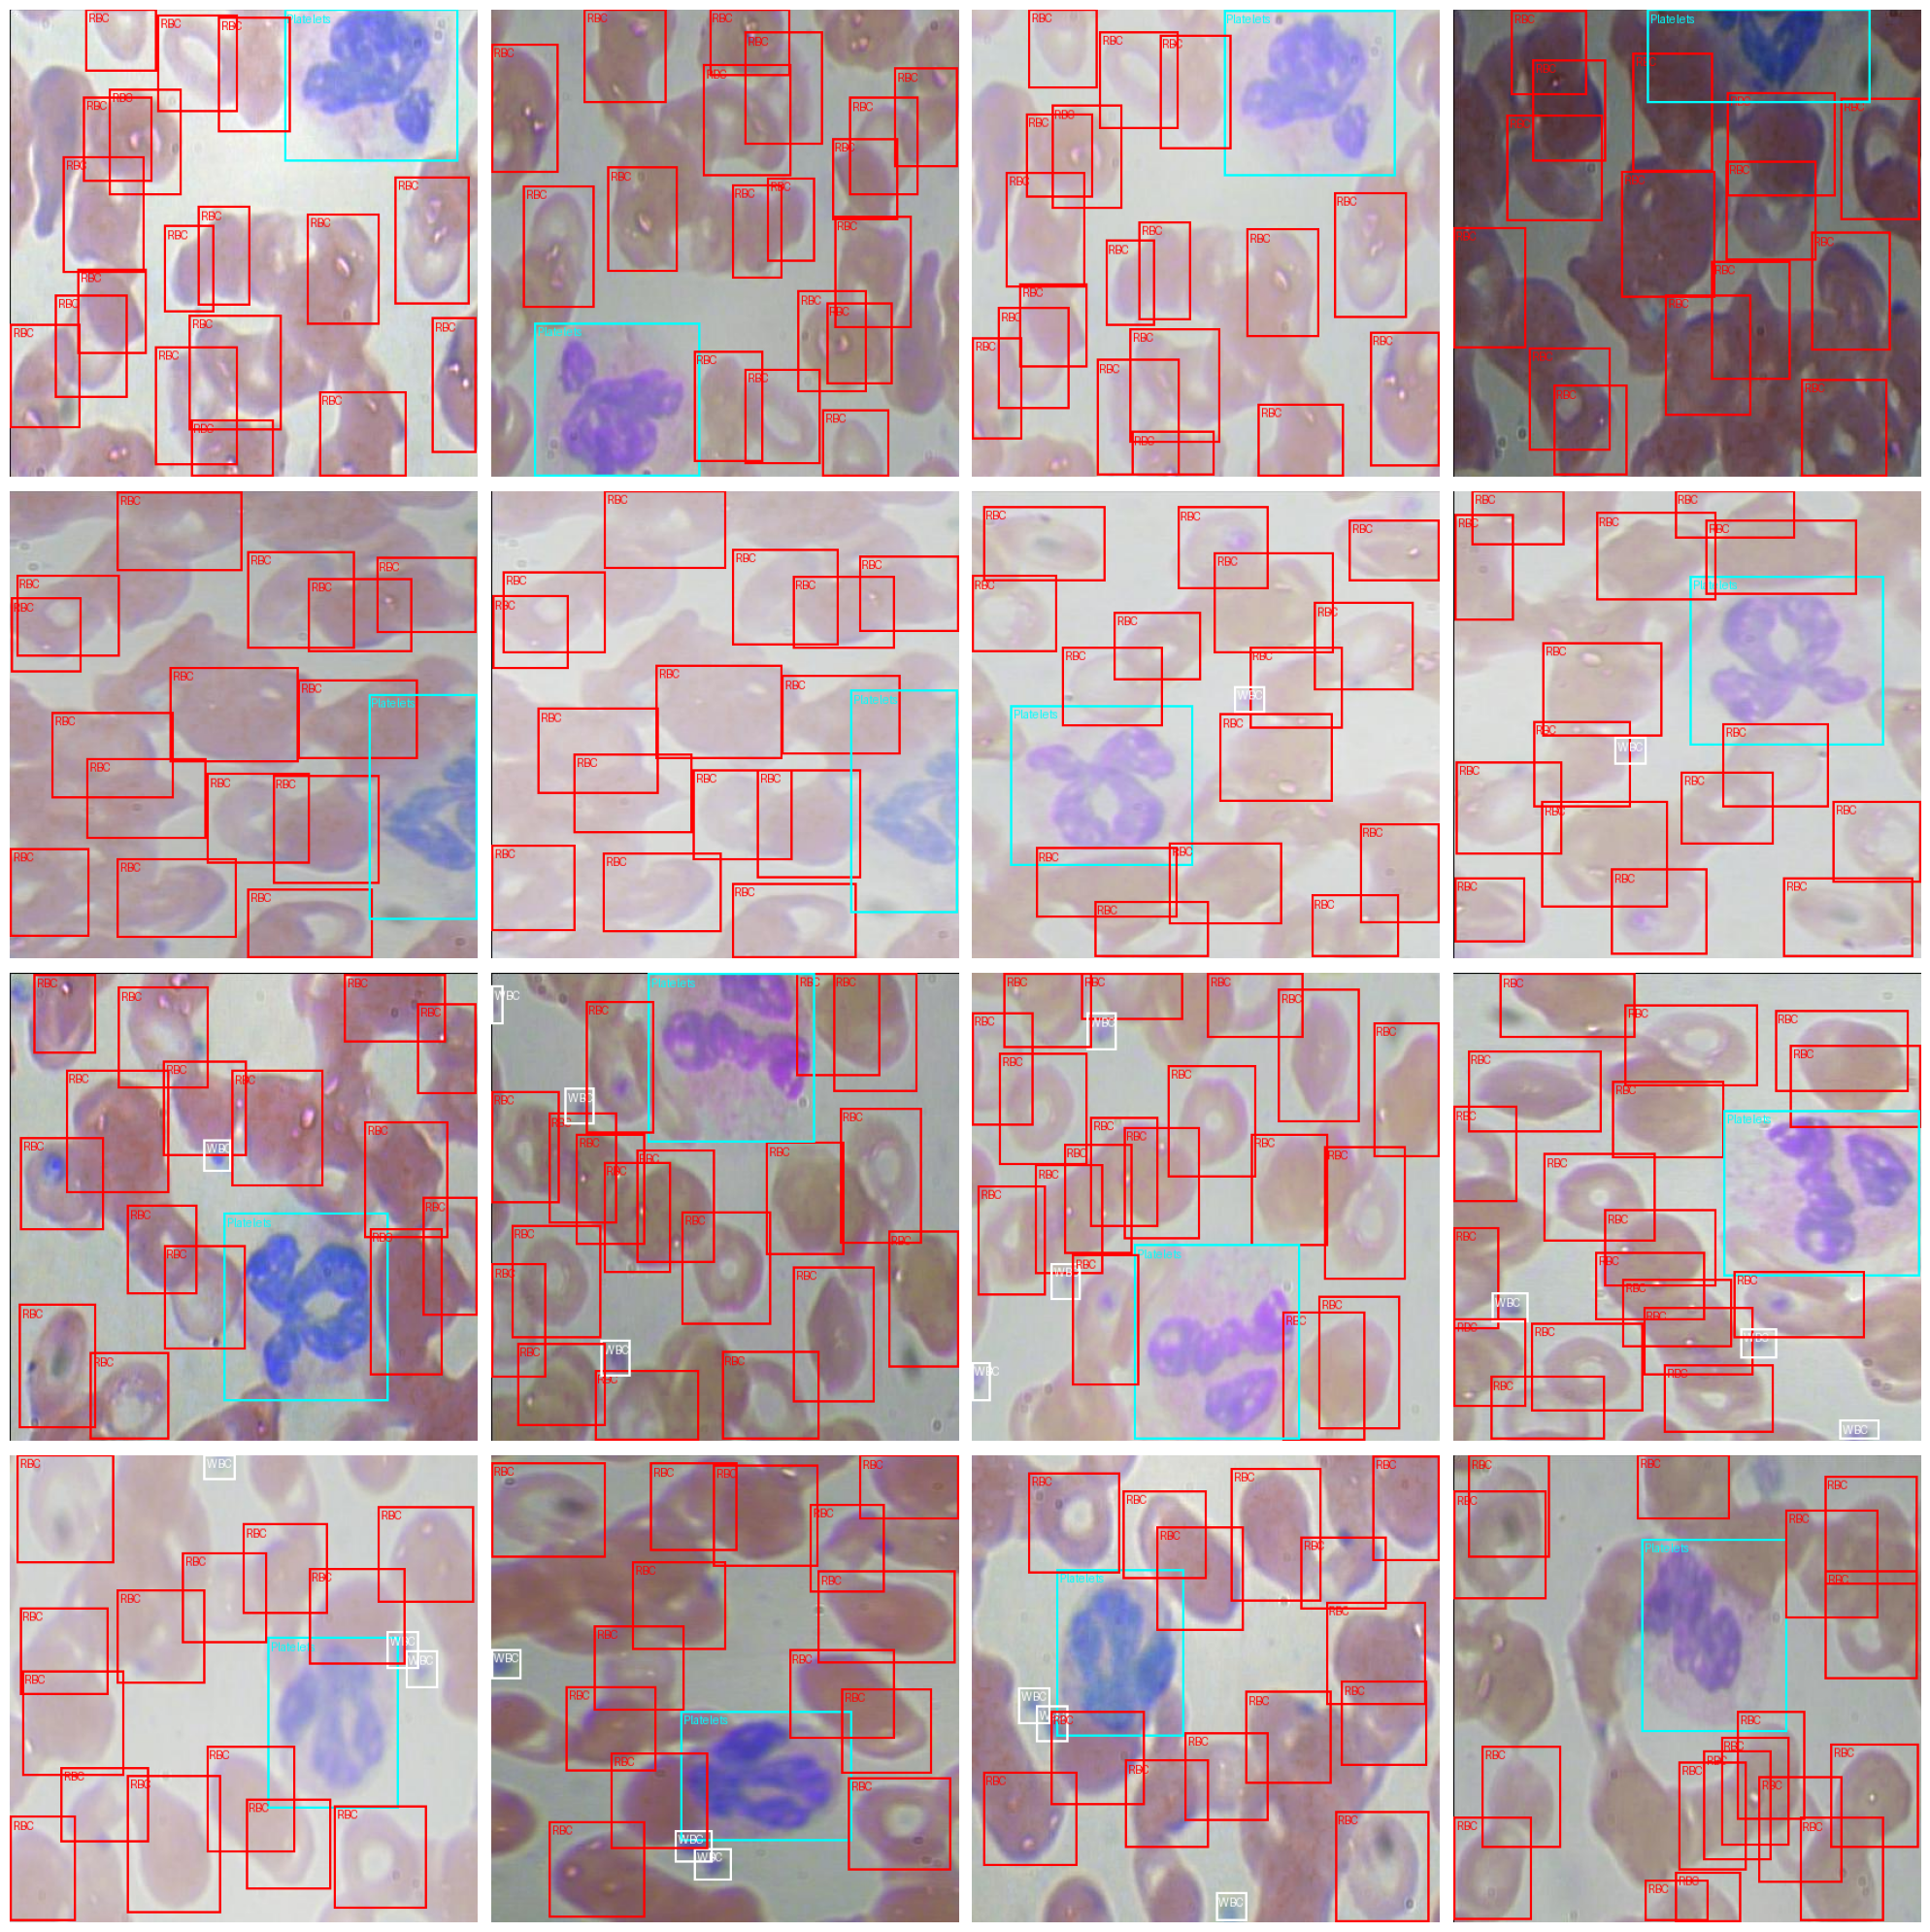

In [ ]:
fig, axes = plt.subplots(4, 4, figsize=(20, 20))

i = 0

while i < 16:

  img_t, target = train_dataset[i]
  boxes = target["boxes"]
  labels = target["labels"]

  ax = axes[i // 4, i % 4]
  image = draw_img_boxes(
      img_t=img_t,
      boxes=boxes,
      labels=labels
  )
  ax.imshow(image)

  ax.axis("off")

  i += 1

plt.tight_layout()

Выполним следующий **алгоритм действий для обучения и тестирования** модели **YOLOv3**\
1. Подберем оптимальные размеры анкеров.
2. Обучим модель YOLOv3 на обучающем наборе данных.
3. Оценим среднее время работы модели при обучении.
4. Подберем оптимальные пороги по confidence и IoU для NMS на валидационной части данных по метрике mAP@.50:.95.
5. Оценим качество модели на тестовых данных по метрикам mAP@.50:.95, mAP@.50, mAP@.75.
6. Оценим время работы модели при тестировании.
7. Визуализируем результаты детекции на нескольких примерах из тестовой части данных.


In [ ]:
def calculate_anchors(
    train_dataset,
    num_anchors=9,
    input_size=416
):
    """
    Вычисляет оптимальные якоря для YOLOv3, используя k-means
    на данных из тренировочной выборки.

    """

    all_scaled_boxes_wh = []

    for img_t, target in train_dataset:
        boxes = target["boxes"]

        if len(boxes) == 0:
            continue

        for box in boxes:

            cx, cy, w, h = box

            if w <= 0 or h <= 0:
                continue


            scaled_w = w * input_size
            scaled_h = h * input_size

            all_scaled_boxes_wh.append([scaled_w, scaled_h])

    if not all_scaled_boxes_wh:
        print("Не найдено ни одного бокса. Невозможно рассчитать анкеры.")
        return None

    all_scaled_boxes_wh = np.array(all_scaled_boxes_wh)
    print(f"Собрано {len(all_scaled_boxes_wh)} боксов для k-means кластеризации.")
    print(f"Диапазон ширин: {all_scaled_boxes_wh[:, 0].min():.1f} - {all_scaled_boxes_wh[:, 0].max():.1f}")
    print(f"Диапазон высот: {all_scaled_boxes_wh[:, 1].min():.1f} - {all_scaled_boxes_wh[:, 1].max():.1f}")

    kmeans = KMeans(n_clusters=num_anchors, random_state=42, n_init=10)
    anchors_labels = kmeans.fit_predict(all_scaled_boxes_wh)

    anchors_pixels = kmeans.cluster_centers_

    plt.figure(figsize=(10, 8))
    plt.scatter(all_scaled_boxes_wh[:, 0], all_scaled_boxes_wh[:, 1], c=anchors_labels, alpha=0.3, label='целевые боксы')
    plt.scatter(anchors_pixels[:, 0], anchors_pixels[:, 1], c="red", marker='*', label='анкеры', s=200, edgecolors='black')
    plt.xlabel('Ширина бокса (пиксели)')
    plt.ylabel('Высота бокса (пиксели)')
    plt.title('K-means кластеризация для anchor boxes')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.gca().set_aspect(1.)

    # 1. Сортируем по площади (от меньшего к большему)
    areas = anchors_pixels[:, 0] * anchors_pixels[:, 1]
    sorted_indices = np.argsort(areas)
    anchors_sorted = anchors_pixels[sorted_indices]

    # 2. Округляем и разбиваем на 3 группы (P3, P4, P5)
    anchors_pixels_rounded = np.round(anchors_sorted).astype(int)

    anchors_p3 = torch.tensor(anchors_pixels_rounded[0:3])  # мелкие
    anchors_p4 = torch.tensor(anchors_pixels_rounded[3:6])  # средние
    anchors_p5 = torch.tensor(anchors_pixels_rounded[6:9])  # крупные

    print("\nРассчитанные анкеры (пиксели, масштаб 416x416):")
    print(f"P3 (мелкие): {anchors_p3.tolist()}")
    print(f"P4 (средние): {anchors_p4.tolist()}")
    print(f"P5 (крупные): {anchors_p5.tolist()}")

    # Возвращаем в том порядке, который ожидает YoloLoss (P5, P4, P3)
    return [anchors_p5, anchors_p4, anchors_p3]


Собрано 10336 боксов для k-means кластеризации.
Диапазон ширин: 5.0 - 250.0
Диапазон высот: 4.0 - 265.0

Рассчитанные анкеры (пиксели, масштаб 416x416):
P3 (мелкие): [[32, 31], [65, 76], [85, 63]]
P4 (средние): [[55, 98], [78, 98], [102, 76]]
P5 (крупные): [[128, 128], [147, 186], [192, 153]]


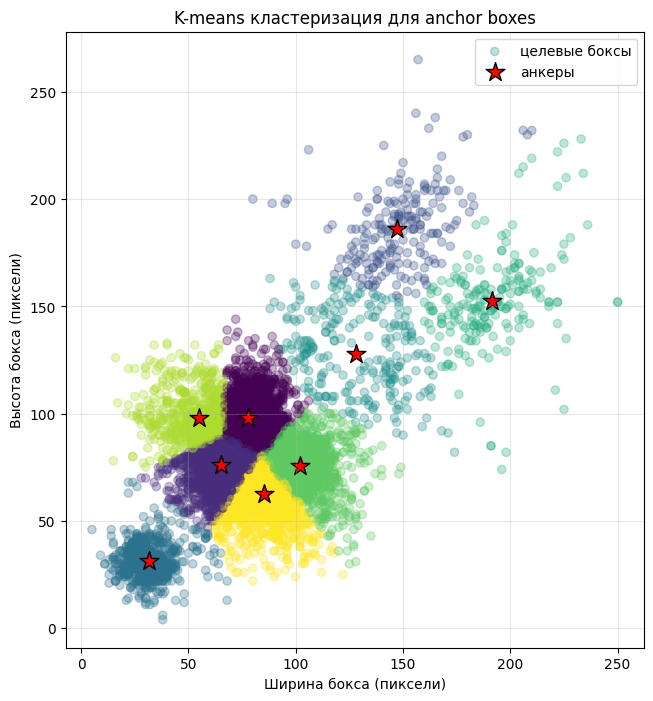

In [ ]:
anchors = calculate_anchors(train_dataset)

In [ ]:
class CNNBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride, padding=None):
        super(CNNBlock, self).__init__()

        if padding is None:
            padding = kernel_size // 2

        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size, stride,
                              padding, bias=False)
        self.bn = nn.BatchNorm2d(out_channels)
        self.activation = nn.LeakyReLU(0.1, inplace=True)

    def forward(self, x):
        return self.activation(self.bn(self.conv(x)))


class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super(ResidualBlock, self).__init__()
        self.block = nn.Sequential(
            CNNBlock(channels, channels // 2, kernel_size=1, stride=1),
            CNNBlock(channels // 2, channels, kernel_size=3, stride=1)
        )

    def forward(self, x):
        return x + self.block(x)

In [ ]:
class Darknet53(nn.Module):
    def __init__(self):
        super().__init__()

        self._make_residual_layer = lambda c, n: nn.Sequential(*[ResidualBlock(c) for _ in range(n)])

        self.conv_in = CNNBlock(3, 32, kernel_size=3, stride=1)

        self.stage1 = nn.Sequential(CNNBlock(32, 64, 3, 2), self._make_residual_layer(64, 1))
        self.stage2 = nn.Sequential(CNNBlock(64, 128, 3, 2), self._make_residual_layer(128, 2))
        self.stage3 = nn.Sequential(CNNBlock(128, 256, 3, 2), self._make_residual_layer(256, 8))
        self.stage4 = nn.Sequential(CNNBlock(256, 512, 3, 2), self._make_residual_layer(512, 8))
        self.stage5 = nn.Sequential(CNNBlock(512, 1024, 3, 2), self._make_residual_layer(1024, 4))

    def forward(self, x):
        x = self.conv_in(x)
        x = self.stage1(x)
        x = self.stage2(x)
        p3 = self.stage3(x)
        p4 = self.stage4(p3)
        p5 = self.stage5(p4)

        return p3, p4, p5

In [ ]:
class YOLONeck_FPN(nn.Module):
    def __init__(self):
        super().__init__()

        self._make_neck = lambda in_c, out_c: nn.Sequential(
            CNNBlock(in_c, out_c, 1, 1),
            CNNBlock(out_c, out_c * 2, 3, 1),
            CNNBlock(out_c * 2, out_c, 1, 1),
            CNNBlock(out_c, out_c * 2, 3, 1),
            CNNBlock(out_c * 2, out_c, 1, 1)
        )

        self._upsample = lambda in_c, out_c: nn.Sequential(
            CNNBlock(in_c, out_c, 1, 1),
            nn.Upsample(scale_factor=2, mode='nearest')
        )

        self.neck_p5 = self._make_neck(1024, 512)
        self.upsample_p5_to_p4 = self._upsample(512, 256)
        self.neck_p4 = self._make_neck(768, 256)
        self.upsample_p4_to_p3 = self._upsample(256, 128)
        self.neck_p3 = self._make_neck(384, 128)

    def forward(self, p3_in, p4_in, p5_in):
        features_p5 = self.neck_p5(p5_in)
        upsampled_p5 = self.upsample_p5_to_p4(features_p5)
        combined_p4 = torch.cat([upsampled_p5, p4_in], dim=1)
        features_p4 = self.neck_p4(combined_p4)
        upsampled_p4 = self.upsample_p4_to_p3(features_p4)
        combined_p3 = torch.cat([upsampled_p4, p3_in], dim=1)
        features_p3 = self.neck_p3(combined_p3)

        return features_p3, features_p4, features_p5


In [ ]:
class PredictionHead(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.head = nn.Sequential(
            CNNBlock(in_channels, in_channels * 2, kernel_size=3, stride=1),
            nn.Conv2d(in_channels * 2, out_channels, kernel_size=1, stride=1, padding=0, bias=True)
        )
    def forward(self, x):
        return self.head(x)


class YOLOHeads(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        out_ch = 3 * (5 + num_classes)
        self.head_p3 = PredictionHead(in_channels=128, out_channels=out_ch)
        self.head_p4 = PredictionHead(in_channels=256, out_channels=out_ch)
        self.head_p5 = PredictionHead(in_channels=512, out_channels=out_ch)

    def forward(self, n3, n4, n5):
        out_p3 = self.head_p3(n3)
        out_p4 = self.head_p4(n4)
        out_p5 = self.head_p5(n5)
        return out_p3, out_p4, out_p5

In [ ]:
class YOLOv3(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        self.backbone = Darknet53()
        self.neck = YOLONeck_FPN()
        self.head = YOLOHeads(num_classes=num_classes)
        self.num_classes = num_classes
        self.num_anchors = 3

    def _format_output(self, tensor):
        B, C, H, W = tensor.shape
        tensor = tensor.view(B, self.num_anchors, -1, H, W)
        tensor = tensor.permute(0, 3, 4, 1, 2).contiguous()
        return tensor

    def forward(self, x):
        p3, p4, p5 = self.backbone(x)
        n3, n4, n5 = self.neck(p3, p4, p5)
        raw_out_p3, raw_out_p4, raw_out_p5 = self.head(n3, n4, n5)
        out_p3 = self._format_output(raw_out_p3)
        out_p4 = self._format_output(raw_out_p4)
        out_p5 = self._format_output(raw_out_p5)
        return [out_p5, out_p4, out_p3]


Yolo loss:

In [ ]:
class BoxLoss(nn.Module):
    """Штрафует за ошибки в предсказании координат бокса"""
    def __init__(self):
        super().__init__()
        self.mse = nn.MSELoss()

    def forward(self, pred_box, target_box, obj_mask):
        if not obj_mask.any():
            return 0.0

        # Loss для координат центра бокса
        loss_box_xy = self.mse(pred_box[..., 0:2][obj_mask], target_box[..., 0:2][obj_mask])

        # Loss для ширины и высоты бокса
        loss_box_wh = self.mse(pred_box[..., 2:4][obj_mask], target_box[..., 2:4][obj_mask])

        return loss_box_xy + loss_box_wh

class ObjectnessLoss(nn.Module):
    """Штрафует за ошибки в предсказании наличия/отсутствия объекта"""
    def __init__(self):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, pred_obj, target_obj, obj_mask, noobj_mask):
        loss_obj = self.bce(pred_obj[obj_mask], target_obj[obj_mask]) if obj_mask.any() else 0.0
        loss_noobj = self.bce(pred_obj[noobj_mask], target_obj[noobj_mask]) if noobj_mask.any() else 0.0
        return loss_obj, loss_noobj

class ClassLoss(nn.Module):
    """Штрафует за ошибки в предсказании класса объекта"""
    def __init__(self):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, pred_class, target_class, obj_mask):
        if not obj_mask.any():
            return 0.0
        loss_class = self.bce(pred_class[obj_mask], target_class[obj_mask])
        return loss_class

In [ ]:
def bbox_iou(box1, box2, x1y1x2y2=True):
    """
    Вычисляет IOU для 2х боксов
    """
    if not x1y1x2y2:
        # Переводим из координат центра и ширины в формат x1y1x2y2
        b1_x1, b1_x2 = box1[:, 0] - box1[:, 2] / 2, box1[:, 0] + box1[:, 2] / 2
        b1_y1, b1_y2 = box1[:, 1] - box1[:, 3] / 2, box1[:, 1] + box1[:, 3] / 2
        b2_x1, b2_x2 = box2[:, 0] - box2[:, 2] / 2, box2[:, 0] + box2[:, 2] / 2
        b2_y1, b2_y2 = box2[:, 1] - box2[:, 3] / 2, box2[:, 1] + box2[:, 3] / 2
    else:
        # Получаем координаты боксов
        b1_x1, b1_y1, b1_x2, b1_y2 = box1[:, 0], box1[:, 1], box1[:, 2], box1[:, 3]
        b2_x1, b2_y1, b2_x2, b2_y2 = box2[:, 0], box2[:, 1], box2[:, 2], box2[:, 3]

    # Считаем координаты квадрата пересечения
    inter_rect_x1 = torch.max(b1_x1, b2_x1)
    inter_rect_y1 = torch.max(b1_y1, b2_y1)
    inter_rect_x2 = torch.min(b1_x2, b2_x2)
    inter_rect_y2 = torch.min(b1_y2, b2_y2)

    # Площадь пересечения
    inter_area = torch.clamp(inter_rect_x2 - inter_rect_x1 + 1, min=0) * torch.clamp(
        inter_rect_y2 - inter_rect_y1 + 1, min=0
    )

    # Площади первого и второго боксов
    b1_area = (b1_x2 - b1_x1 + 1) * (b1_y2 - b1_y1 + 1)
    b2_area = (b2_x2 - b2_x1 + 1) * (b2_y2 - b2_y1 + 1)

    # IoU
    iou = inter_area / (b1_area + b2_area - inter_area + 1e-16)

    return iou

In [ ]:
class TargetBuilder(nn.Module):
    def __init__(self, anchors_by_scale, num_classes=7, ignore_thresh=0.5):
        """
        Инициализирует TargetBuilder для создания целевых меток YOLO.

        Args:
            anchors_by_scale (list of torch.Tensor): Список тензоров, где каждый тензор содержит якоря [width, height]
                                                   для соответствующего масштаба (P5, P4, P3).
            num_classes (int, optional): Количество классов для обнаружения. По умолчанию 7.
            ignore_thresh (float, optional): IoU-порог, выше которого предсказания считаются 'игнорируемыми'
                                           для расчета objectness loss. По умолчанию 0.5.
        """
        super().__init__()
        self.num_classes = num_classes
        self.ignore_thresh = ignore_thresh

        # self.anchors - это анкеры в ПИКСЕЛЯХ (e.g., [116, 90])
        self.anchors = anchors_by_scale
        self.num_anchors = 3

        # Размеры сеток
        self.grid_sizes = [13, 26, 52]
        # Страйды для 416x416.
        # (416/13=32, 416/26=16, 416/52=8)
        self.strides = [32, 16, 8]
        # Масштабированные анкеры.
        # Мы делим пиксельные анкеры на страйд, чтобы получить
        # анкеры в "сеточных" единицах (grid units)
        self.anchors_grid_units = [
            anchors.float() / stride
            for anchors, stride in zip(self.anchors, self.strides)
        ]


    def forward(self, predictions, targets):
        """
        Создает целевые тензоры для YOLO-Loss.

        Args:
            predictions (list of torch.Tensor): Список предсказаний модели для каждого масштаба (P5, P4, P3).
                                              Каждый тензор имеет форму (B, S, S, num_anchors, 5 + num_classes).
            targets (torch.Tensor): Тензор истинных меток (Ground Truth) объектов в батче.
                                    Формат: (N, 6), где N - общее количество объектов в батче,
                                    а 6 включает [batch_idx, class_id, cx, cy, w, h] (нормализованные).

        Returns:
            tuple: Кортеж из трех списков:
                - all_obj_masks (list of torch.Tensor): Маски, указывающие, какие якоря соответствуют объектам.
                - all_noobj_masks (list of torch.Tensor): Маски, указывающие, какие якоря не соответствуют объектам
                                                        и не игнорируются.
                - all_target_tensors (list of torch.Tensor): Целевые тензоры для каждой головы YOLO.
                                                           Формат: (B, S, S, num_anchors, 5 + num_classes).
        """
        all_obj_masks = []
        all_noobj_masks = []
        all_target_tensors = []

        # (predictions идет в порядке P5, P4, P3,
        # поэтому grid_sizes и anchors должны быть в том же порядке)
        for scale_idx, p in enumerate(predictions):
            B, S, _, A, _ = p.shape # S = 13, 26, или 52 (grid_size)

            obj_mask = torch.zeros((B, S, S, A), dtype=torch.bool, device=p.device)
            noobj_mask = torch.ones((B, S, S, A), dtype=torch.bool, device=p.device)
            target_box_coords = torch.zeros((B, S, S, A, 4), device=p.device)
            target_obj_conf = torch.zeros((B, S, S, A, 1), device=p.device)
            target_class_probs = torch.zeros((B, S, S, A, self.num_classes), device=p.device)

            # Берем анкеры, УЖЕ сконвертированные в "сеточные" единицы
            current_anchors_grid = self.anchors_grid_units[scale_idx].to(p.device)

            for t in targets:
                batch_idx, t_class, t_x, t_y, t_w, t_h = t
                batch_idx = int(batch_idx)

                # --- Приводим GT к "сеточным" единицам ---
                # (t_x, t_y, t_w, t_h) - нормализованные (0-1)

                # Координаты центра в "сеточных" единицах
                t_x_grid = t_x * S
                t_y_grid = t_y * S
                # Ширина и высота в "сеточных" единицах
                t_w_grid = t_w * S
                t_h_grid = t_h * S

                # Индексы ячейки (i, j)
                j, i = int(t_x_grid), int(t_y_grid)
                if i >= S or j >= S:
                    continue # пропустить, если бокс за пределами сетки

                # 1. GT бокс (в "сеточных" единицах)
                gt_box_grid = torch.tensor([0, 0, t_w_grid, t_h_grid], device=p.device).unsqueeze(0)

                # 2. Анкеры (в "сеточных" единицах)
                anchor_shapes_grid = torch.cat([
                    torch.zeros_like(current_anchors_grid),
                    current_anchors_grid
                ], dim=1)

                # 3. Считаем IoU
                ious = bbox_iou(gt_box_grid, anchor_shapes_grid, x1y1x2y2=False)

                # 4. Находим походящий анкер
                best_a = ious.argmax()

                # 5. Обновляем маски, указывающие, какие якоря соответствуют объектам,
                # и маски, указывающие, какие якоря не соответствуют объектам и не игнорируются.
                obj_mask[batch_idx, i, j, best_a] = 1
                noobj_mask[batch_idx, i, j, best_a] = 0
                noobj_mask[batch_idx, i, j, ious > self.ignore_thresh] = 0

                # 6. Считаем смещение центра таргета от центра ячейки
                target_box_coords[batch_idx, i, j, best_a, 0] = t_x_grid - j
                target_box_coords[batch_idx, i, j, best_a, 1] = t_y_grid - i

                # 7. Считаем отличия в масштабе размеров таргета от размеров анкера
                target_box_coords[batch_idx, i, j, best_a, 2] = torch.log(
                    t_w_grid / current_anchors_grid[best_a, 0] + 1e-16
                )
                target_box_coords[batch_idx, i, j, best_a, 3] = torch.log(
                    t_h_grid / current_anchors_grid[best_a, 1] + 1e-16
                )

                # 8. Также записываем конфиденс и вероятность для нужного анкера для нужного класса
                target_obj_conf[batch_idx, i, j, best_a] = 1.0
                target_class_probs[batch_idx, i, j, best_a, int(t_class)] = 1.0

            all_obj_masks.append(obj_mask)
            all_noobj_masks.append(noobj_mask)
            all_target_tensors.append(
                torch.cat([target_box_coords, target_obj_conf, target_class_probs], dim=-1)
            )

        return all_obj_masks, all_noobj_masks, all_target_tensors

In [ ]:
class YoloLoss(nn.Module):
    def __init__(self, anchors_by_scale, num_classes=3, ignore_thresh=0.5):
        """
        Инициализирует функцию потерь YOLO (YoloLoss).

        Args:
            anchors_by_scale (list of torch.Tensor): Список тензоров, где каждый тензор содержит якоря [width, height]
                                                   для соответствующего масштаба (P5, P4, P3).
            num_classes (int, optional): Количество классов для обнаружения. По умолчанию 3.
            ignore_thresh (float, optional): IoU-порог для игнорирования предсказаний без объектов.
                                           По умолчанию 0.5.
        """
        super().__init__()
        self.target_builder = TargetBuilder(anchors_by_scale, num_classes, ignore_thresh)
        self.box_loss_fn = BoxLoss()
        self.obj_loss_fn = ObjectnessLoss()
        self.cls_loss_fn = ClassLoss()
        self.lambda_class = 1.0
        self.lambda_obj = 1.0
        self.lambda_noobj = 10.0
        self.lambda_box = 10.0

    def forward(self, predictions, targets):
        """
        Вычисляет общую функцию потерь YOLO для данного батча.

        Args:
            predictions (list of torch.Tensor): Список предсказаний модели для каждого масштаба (P5, P4, P3).
                                              Каждый тензор имеет форму (B, S, S, num_anchors, 5 + num_classes).
            targets (torch.Tensor): Тензор истинных меток (Ground Truth) объектов в батче.
                                    Формат: (N, 6), где N - общее количество объектов в батче,
                                    а 6 включает [batch_idx, class_id, cx, cy, w, h] (нормализованные).

        Returns:
            torch.Tensor: Общая функция потерь для батча.
        """
        # 1. Построение целевых тензоров (ground truth) для каждого масштаба
        # Это включает маски для объектов, отсутствия объектов и форматированные целевые данные
        obj_masks, noobj_masks, target_tensors = self.target_builder(predictions, targets)

        total_loss = 0
        # Получаем размер батча из первого предсказания
        B = predictions[0].shape[0]

        # 2. Итерация по каждому масштабу предсказаний (P5, P4, P3)
        for i, p in enumerate(predictions):
            # Разделение предсказаний на компоненты: координаты бокса, уверенность в объекте, вероятности классов
            pred_box = p[..., 0:4]      # (tx, ty, tw, th)
            pred_obj = p[..., 4:5]      # (to) objectness score
            pred_class = p[..., 5:]     # (c1, c2, ..., cn) class probabilities

            # Извлечение соответствующих целевых данных для текущего масштаба
            target_box = target_tensors[i][..., 0:4]
            target_obj = target_tensors[i][..., 4:5]
            target_class = target_tensors[i][..., 5:]

            # Извлечение масок для объектов и отсутствия объектов
            obj_mask = obj_masks[i]
            noobj_mask = noobj_masks[i]

            # 3. Вычисление отдельных компонентов лосс
            loss_box = self.box_loss_fn(pred_box, target_box, obj_mask)
            loss_obj, loss_noobj = self.obj_loss_fn(pred_obj, target_obj, obj_mask, noobj_mask)
            loss_class = self.cls_loss_fn(pred_class, target_class, obj_mask)

            # 4. Комбинирование компонентов лосса с весами
            # Эти веса (лямбды) позволяют настроить важность каждого типа ошибки
            scale_loss = (
                self.lambda_box * loss_box +
                self.lambda_obj * loss_obj +
                self.lambda_noobj * loss_noobj +
                self.lambda_class * loss_class
            )
            # Добавление лосса текущего масштаба к общему лоссу
            total_loss += scale_loss

        # 5. Нормализация общего лосса по размеру батча
        return total_loss / B

In [ ]:
class AverageMeter:
    """Вычисляет и хранит среднее значения"""
    def __init__(self):
        self.reset()

    def reset(self):
        self.val = 0
        self.avg = 0
        self.sum = 0
        self.count = 0

    def update(self, val, n=1):
        self.val = val
        self.sum += val * n
        self.count += n
        self.avg = self.sum / self.count

def prepare_targets(boxes, labels, device):
    """Подготавливаем targets для YOLO loss"""
    targets = []
    for batch_idx, (batch_boxes, batch_labels) in enumerate(zip(boxes, labels)):
        for box, label in zip(batch_boxes, batch_labels):
            if len(box) == 4:  # cx, cy, w, h
                cx, cy, w, h = box
                targets.append([batch_idx, label, cx, cy, w, h])
    return torch.tensor(targets, device=device) if targets else torch.tensor([], device=device)

def train(train_loader, model, criterion, optimizer, history, epoch, n_epochs, device, print_freq=10):
    """Тренировка одной эпохи с измерением времени"""
    model.train()

    # Метрики для измерения времени
    batch_time = AverageMeter()
    data_time = AverageMeter()
    epoch_time = AverageMeter()
    losses = AverageMeter()

    start_epoch = time.time()

    for i, (images, boxes, labels) in enumerate(train_loader):
        start_batch = time.time()
        data_time.update(time.time() - start_batch)

        images = images.to(device)

        # Подготавливаем targets
        targets = prepare_targets(boxes, labels, device)

        # Forward prop.
        predictions = model(images)

        # Loss
        loss = criterion(predictions, targets)

        # Backward prop.
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        losses.update(loss.item(), images.size(0))
        batch_time.update(time.time() - start_batch)

        history['loss'].append(loss.item())

        if i % print_freq == 0:
            print(f'Epoch: {epoch}/{n_epochs}\t'
                  f'Batch {i}/{len(train_loader)}\t'
                  f'Loss {losses.val:.4f} ({losses.avg:.4f})\t'
                  f'Batch Time {batch_time.val:.3f}s\t'
                  f'Data Time {data_time.val:.3f}s')

    epoch_time.update(time.time() - start_epoch)

    return epoch_time.avg, batch_time.avg, data_time.avg

def save_checkpoint(state_path, epoch, model, optimizer, history):
    """Сохраняем чекпоинт модели."""
    state = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'history': history,
    }
    torch.save(state, state_path)

def load_checkpoint(state_path, model, optimizer):
    """Загружаем чекпоинт модели."""
    if os.path.exists(state_path):
        checkpoint = torch.load(state_path, map_location='cpu')
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        history = checkpoint['history']
        start_epoch = checkpoint['epoch'] + 1
        print(f'Loaded checkpoint from epoch {start_epoch-1}')
        return start_epoch, history
    else:
        return 0, {'loss': []}

def train_yolov3(model, train_loader, criterion, optimizer, device, n_epochs=100, checkpoint_path='yolov3_checkpoint.pth'):
    """Основная функция обучения YOLOv3"""


    history = {
        'loss': [],
        'epoch_times': [],
        'batch_times': [],
        'data_times': []
    }


    start_epoch, loaded_history = load_checkpoint(checkpoint_path, model, optimizer)
    if start_epoch > 0:
        history = loaded_history

    print(f"Starting training from epoch {start_epoch} to {n_epochs}")
    print(f"Training on: {device}")
    print(f"Number of batches per epoch: {len(train_loader)}")

    total_training_time = 0

    for epoch in range(start_epoch, n_epochs):

        print(f"Epoch {epoch}/{n_epochs}")


        epoch_time, avg_batch_time, avg_data_time = train(
            train_loader, model, criterion, optimizer, history,
            epoch, n_epochs, device
        )


        history['epoch_times'].append(epoch_time)
        history['batch_times'].append(avg_batch_time)
        history['data_times'].append(avg_data_time)
        total_training_time += epoch_time


        print(f"\nEpoch {epoch} Time Statistics:")
        print(f"  Epoch Time: {epoch_time:.2f} seconds")
        print(f"  Avg Batch Time: {avg_batch_time:.3f} seconds")
        print(f"  Avg Data Loading Time: {avg_data_time:.3f} seconds")
        print(f"  Total Training Time: {total_training_time:.2f} seconds")

        if epoch % 10 == 0:
            save_checkpoint(checkpoint_path, epoch, model, optimizer, history)
            print(f"Checkpoint saved at epoch {epoch}")


    save_checkpoint(checkpoint_path, n_epochs, model, optimizer, history)


    print(f"Total Epochs Trained: {n_epochs - start_epoch}")
    print(f"Total Training Time: {total_training_time:.2f} seconds")
    print(f"Average Epoch Time: {total_training_time / (n_epochs - start_epoch):.2f} seconds")

    if history['batch_times']:
        avg_batch = sum(history['batch_times']) / len(history['batch_times'])
        print(f"Average Batch Time: {avg_batch:.3f} seconds")

    if history['data_times']:
        avg_data = sum(history['data_times']) / len(history['data_times'])
        print(f"Average Data Loading Time: {avg_data:.3f} seconds")

    return history

In [ ]:
# Инициализация модели
model = YOLOv3(num_classes=3)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=5e-4)
criterion = YoloLoss(anchors, num_classes=3)

# Загрузка чекпоинта если есть
start_epoch, history = load_checkpoint("checkpoint_yolov3.pth", model, optimizer)

model = model.to(device)
criterion = criterion.to(device)

# Обучение
for epoch in range(start_epoch, 50):
    train(train_loader=train_dataloader,
          model=model,
          criterion=criterion,
          optimizer=optimizer,
          history=history,
          epoch=epoch,
          n_epochs=50,
          device=device,
          print_freq=20)

    # Сохраняем чекпоинт
    save_checkpoint("checkpoint_yolov3.pth", epoch, model, optimizer, history)

Epoch: 0/50	Batch 0/96	Loss 6.9483 (6.9483)	Batch Time 2.465s	Data Time 0.000s
Epoch: 0/50	Batch 20/96	Loss 3.8608 (7.4031)	Batch Time 0.871s	Data Time 0.000s
Epoch: 0/50	Batch 40/96	Loss 3.0302 (7.7100)	Batch Time 0.887s	Data Time 0.000s
Epoch: 0/50	Batch 60/96	Loss 2.5500 (6.0682)	Batch Time 0.835s	Data Time 0.000s
Epoch: 0/50	Batch 80/96	Loss 2.2943 (6.2524)	Batch Time 1.102s	Data Time 0.000s
Epoch: 1/50	Batch 0/96	Loss 2.0853 (2.0853)	Batch Time 1.201s	Data Time 0.000s
Epoch: 1/50	Batch 20/96	Loss 1.9748 (4.3994)	Batch Time 0.750s	Data Time 0.000s
Epoch: 1/50	Batch 40/96	Loss 1.8282 (3.1890)	Batch Time 0.856s	Data Time 0.000s
Epoch: 1/50	Batch 60/96	Loss 2.1913 (4.3237)	Batch Time 0.800s	Data Time 0.000s
Epoch: 1/50	Batch 80/96	Loss 2.1553 (5.2229)	Batch Time 0.814s	Data Time 0.000s
Epoch: 2/50	Batch 0/96	Loss 1.7630 (1.7630)	Batch Time 1.071s	Data Time 0.000s
Epoch: 2/50	Batch 20/96	Loss 1.6187 (1.7533)	Batch Time 0.860s	Data Time 0.000s
Epoch: 2/50	Batch 40/96	Loss 1.7752 (5.2516

4. Подберем оптимальные пороги по confidence и IoU для NMS на валидационной части данных по метрике mAP@.50:.95 - это значит, что mean Average Precision at IoU thresholds from 0.50 to 0.95:

In [ ]:
def decode_predictions(predictions, anchors, grid_sizes, num_classes, input_size, conf_threshold=0.5):
    all_boxes = []
    device = predictions[0].device
    anchors = [a.to(device) for a in anchors]

    for i, (p, S) in enumerate(zip(predictions, grid_sizes)):
        B, _, _, A, C = p.shape

        grid_y, grid_x = torch.meshgrid(torch.arange(S), torch.arange(S), indexing='ij')
        grid = torch.stack((grid_x, grid_y), dim=-1).float().to(device).view(1, S, S, 1, 2)

        stride = input_size / S
        scaled_anchors = (anchors[i] / stride).view(1, 1, 1, A, 2)

        pred_xy = torch.sigmoid(p[..., 0:2]) + grid
        box_xy = pred_xy * stride

        pred_wh = torch.exp(p[..., 2:4]) * scaled_anchors
        box_wh = pred_wh * stride

        objectness = torch.sigmoid(p[..., 4:5])
        class_probs = torch.sigmoid(p[..., 5:])

        p_flat = p.view(B, -1, C)
        box_xy_flat = box_xy.view(B, -1, 2)
        box_wh_flat = box_wh.view(B, -1, 2)
        objectness_flat = objectness.view(B, -1, 1)
        class_probs_flat = class_probs.view(B, -1, num_classes)

        box_x1y1 = box_xy_flat - box_wh_flat / 2
        box_x2y2 = box_xy_flat + box_wh_flat / 2
        boxes_xyxy = torch.cat([box_x1y1, box_x2y2], dim=-1)

        scores, class_indices = torch.max(class_probs_flat * objectness_flat, dim=-1)

        mask = scores > conf_threshold

        boxes_xyxy_filtered = boxes_xyxy[0, mask[0]]
        scores_filtered = scores[0, mask[0]]
        class_indices_filtered = class_indices[0, mask[0]]

        if boxes_xyxy_filtered.shape[0] > 0:
            all_boxes.append(torch.cat([
                boxes_xyxy_filtered,
                scores_filtered.unsqueeze(-1),
                class_indices_filtered.unsqueeze(-1).float()
            ], dim=-1))

    if not all_boxes:
        return torch.empty(0, 6, device=device)

    all_boxes_cat = torch.cat(all_boxes, dim=0)
    return all_boxes_cat

In [ ]:
def find_optimal_thresholds(results):
    """Ищет оптимальные пороги по mAP@.50:.95"""
    best_score = 0
    best_thresholds = (0.5, 0.5)

    for thresholds, metrics in results.items():
        conf_thresh, iou_thresh = thresholds
        map_score = metrics['mAP@.50:.95']

        if map_score > best_score:
            best_score = map_score
            best_thresholds = (conf_thresh, iou_thresh)

    return best_thresholds, best_score

In [ ]:
def nms(decoded_boxes, iou_threshold=0.45):
    """
    Выполняет Non-Maximum Suppression (NMS)
    """
    if decoded_boxes.shape[0] == 0:
        return torch.empty(0, 6)

    boxes_list = decoded_boxes.clone()
    final_boxes = []

    while boxes_list.shape[0] > 0:

        # 1. Сортируем оставшиеся боксы по score
        order = boxes_list[:, 4].argsort(descending=True)
        boxes_list = boxes_list[order]

        # 2. Берем лучший бокс
        best_box = boxes_list[0]
        final_boxes.append(best_box)

        if boxes_list.shape[0] == 1:
            break

        # 3. Берем все остальные боксы
        other_boxes = boxes_list[1:]

        # 4. Считаем IoU лучшего бокса со всеми остальными
        iou = bbox_iou(best_box[:4].unsqueeze(0), other_boxes[:, :4])

        # 5. Оставляем только те, у которых IoU <= порога
        non_overlapping_mask = iou <= iou_threshold

        # 6. Обновляем список на следующую итерацию
        boxes_list = other_boxes[non_overlapping_mask]

    if not final_boxes:
        return torch.empty(0, 6)

    return torch.stack(final_boxes)

Побираем оптимальные пороги:

In [ ]:
def evaluate_with_thresholds(model, dataset, anchors, grid_sizes, num_classes,
                           conf_threshold=0.01, iou_threshold=0.45):

    loader = DataLoader(
        dataset,
        batch_size=8,
        shuffle=False,
        collate_fn=collate_fn
    )

    model.eval()
    metric = MeanAveragePrecision(box_format='xyxy', class_metrics=True)

    total_inference_time = 0
    total_samples = 0

    for images_batch, boxes_batch_norm, labels_batch in tqdm(loader):
        images_batch = images_batch.to(device)

        start_time = time.time()
        with torch.no_grad():
            predictions_raw = model(images_batch)
            batch_preds_formatted = []

            for i in range(images_batch.shape[0]):
                preds_i = [p[i:i+1] for p in predictions_raw]

                decoded_boxes = decode_predictions(
                    preds_i, anchors, grid_sizes,
                    num_classes=num_classes,
                    input_size=416,
                    conf_threshold=conf_threshold
                )

                nms_boxes = nms(decoded_boxes, iou_threshold=iou_threshold)

                if len(nms_boxes) > 0:
                    batch_preds_formatted.append({
                        'boxes': nms_boxes[:, :4].cpu(),
                        'scores': nms_boxes[:, 4].cpu(),
                        'labels': nms_boxes[:, 5].int().cpu()
                    })
                else:
                    batch_preds_formatted.append({
                        'boxes': torch.empty(0, 4),
                        'scores': torch.empty(0),
                        'labels': torch.empty(0, dtype=torch.int)
                    })


        batch_target_formatted = []
        for i in range(len(boxes_batch_norm)):
            boxes_i = boxes_batch_norm[i]
            if len(boxes_i) > 0:

                target_boxes_abs = []
                for box in boxes_i:
                    cx, cy, w, h = box
                    xmin, ymin, xmax, ymax = cxcywh_to_x1y1x2y2(cx, cy, w, h)
                    target_boxes_abs.append([xmin, ymin, xmax, ymax])

                batch_target_formatted.append({
                    'boxes': torch.tensor(target_boxes_abs).cpu(),
                    'labels': labels_batch[i].int().cpu()
                })
            else:
                batch_target_formatted.append({
                    'boxes': torch.empty(0, 4),
                    'labels': torch.empty(0, dtype=torch.int)
                })

        metric.update(batch_preds_formatted, batch_target_formatted)

        batch_time = time.time() - start_time
        total_inference_time += batch_time
        total_samples += len(images_batch)

    results = metric.compute()
    avg_time_per_sample = total_inference_time / total_samples

    return results, avg_time_per_sample

In [ ]:
def find_optimal_thresholds_on_validation(checkpoint_path, val_dataset, anchors, grid_sizes, num_classes):
    """
    Подбирает оптимальные confidence и IoU пороги на валидационных данных
    """

    model = YOLOv3(num_classes=num_classes).to(device)
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])


    conf_thresholds = [0.01, 0.1, 0.2, 0.3, 0.4, 0.5]
    iou_thresholds = [0.3, 0.4, 0.5, 0.6]

    best_map = 0
    best_conf = 0.01
    best_iou = 0.45
    results_dict = {}


    for conf in conf_thresholds:
        for iou in iou_thresholds:
            print(f"Testing: conf_thresh={conf:.2f}, iou_thresh={iou:.2f}")


            metrics, _ = evaluate_with_thresholds(
                model, val_dataset, anchors, grid_sizes, num_classes,
                conf_threshold=conf,
                iou_threshold=iou
            )

            current_map = metrics['map'].item()

            results_dict[(conf, iou)] = {
                'mAP@.50:.95': current_map,
                'mAP@.50': metrics['map_50'].item(),
                'mAP@.75': metrics['map_75'].item()
            }

            print(f"  mAP@.50:.95 = {current_map:.4f}")

            if current_map > best_map:
                best_map = current_map
                best_conf = conf
                best_iou = iou


    print(f"\n Оптимальные пороги:")
    print(f"   Confidence threshold: {best_conf:.2f}")
    print(f"   IoU threshold: {best_iou:.2f}")
    print(f"   mAP@.50:.95: {best_map:.4f}")

    return best_conf, best_iou, results_dict

In [ ]:
GRID_SIZES=[13, 26, 52]
best_conf, best_iou, val_results = find_optimal_thresholds_on_validation(
    checkpoint_path="checkpoint_yolov3.pth",
    val_dataset=val_dataset,
    anchors=anchors,
    grid_sizes=GRID_SIZES,
    num_classes=3
)

Testing: conf_thresh=0.01, iou_thresh=0.30


  0%|          | 0/10 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: Encountered more than 100 detections in a single image. This means that certain detections with the lowest scores will be ignored, that may have an undesirable impact on performance. Please consider adjusting the `max_detection_threshold` to suit your use case. To disable this warning, set attribute class `warn_on_many_detections=False`, after initializing the metric.
  warnings.warn(*args, **kwargs)
100%|██████████| 10/10 [00:06<00:00,  1.60it/s]


  mAP@.50:.95 = 0.4121
Testing: conf_thresh=0.01, iou_thresh=0.40


100%|██████████| 10/10 [00:07<00:00,  1.25it/s]


  mAP@.50:.95 = 0.4174
Testing: conf_thresh=0.01, iou_thresh=0.50


...

  mAP@.50:.95 = 0.4149
Testing: conf_thresh=0.50, iou_thresh=0.50


100%|██████████| 10/10 [00:02<00:00,  3.56it/s]


  mAP@.50:.95 = 0.4172
Testing: conf_thresh=0.50, iou_thresh=0.60


100%|██████████| 10/10 [00:03<00:00,  2.74it/s]


  mAP@.50:.95 = 0.4177

 Оптимальные пороги:
   Confidence threshold: 0.01
   IoU threshold: 0.60
   mAP@.50:.95: 0.4212


In [ ]:
def evaluate_custom_model(checkpoint_path, test_dataset, anchors, grid_sizes, num_classes,
                                 conf_threshold=0.01, iou_threshold=0.45):

    model = YOLOv3(num_classes=num_classes).to(device)
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])

    print(f"Тестирование с порогами: conf={conf_threshold:.2f}, iou={iou_threshold:.2f}")

    results, avg_time = evaluate_with_thresholds(
        model, test_dataset, anchors, grid_sizes, num_classes,
        conf_threshold=conf_threshold,
        iou_threshold=iou_threshold
    )

    print(f"   mAP@.50:.95: {results['map'].item():.4f}")
    print(f"   mAP@.50: {results['map_50'].item():.4f}")
    print(f"   mAP@.75: {results['map_75'].item():.4f}")
    print(f"   Среднее время на изображение: {avg_time:.4f} сек")
    print(f"   FPS: {1/avg_time:.2f}")

    return results, avg_time

In [ ]:
test_results = evaluate_custom_model(
    checkpoint_path="checkpoint_yolov3.pth",
    test_dataset=test_dataset,
    anchors=anchors,
    grid_sizes=GRID_SIZES,
    num_classes=3,
    conf_threshold=best_conf,
    iou_threshold=best_iou
)


Тестирование с порогами: conf=0.01, iou=0.60


100%|██████████| 5/5 [00:09<00:00,  1.93s/it]


   mAP@.50:.95: 0.4087
   mAP@.50: 0.7770
   mAP@.75: 0.3656
   Среднее время на изображение: 0.2639 сек
   FPS: 3.79


Визуализация:

In [ ]:
def scale_boxes(boxes, img_shape_416, img_shape_orig):
    input_w, input_h = img_shape_416
    orig_w, orig_h = img_shape_orig

    scale_x = orig_w / input_w
    scale_y = orig_h / input_h

    boxes_scaled = boxes.clone()
    boxes_scaled[:, 0] *= scale_x # x1
    boxes_scaled[:, 1] *= scale_y # y1
    boxes_scaled[:, 2] *= scale_x # x2
    boxes_scaled[:, 3] *= scale_y # y2

    boxes_scaled[:, 0] = torch.clamp(boxes_scaled[:, 0], 0, orig_w)
    boxes_scaled[:, 1] = torch.clamp(boxes_scaled[:, 1], 0, orig_h)
    boxes_scaled[:, 2] = torch.clamp(boxes_scaled[:, 2], 0, orig_w)
    boxes_scaled[:, 3] = torch.clamp(boxes_scaled[:, 3], 0, orig_h)

    return boxes_scaled


Запуск инференса на 5 изображениях...


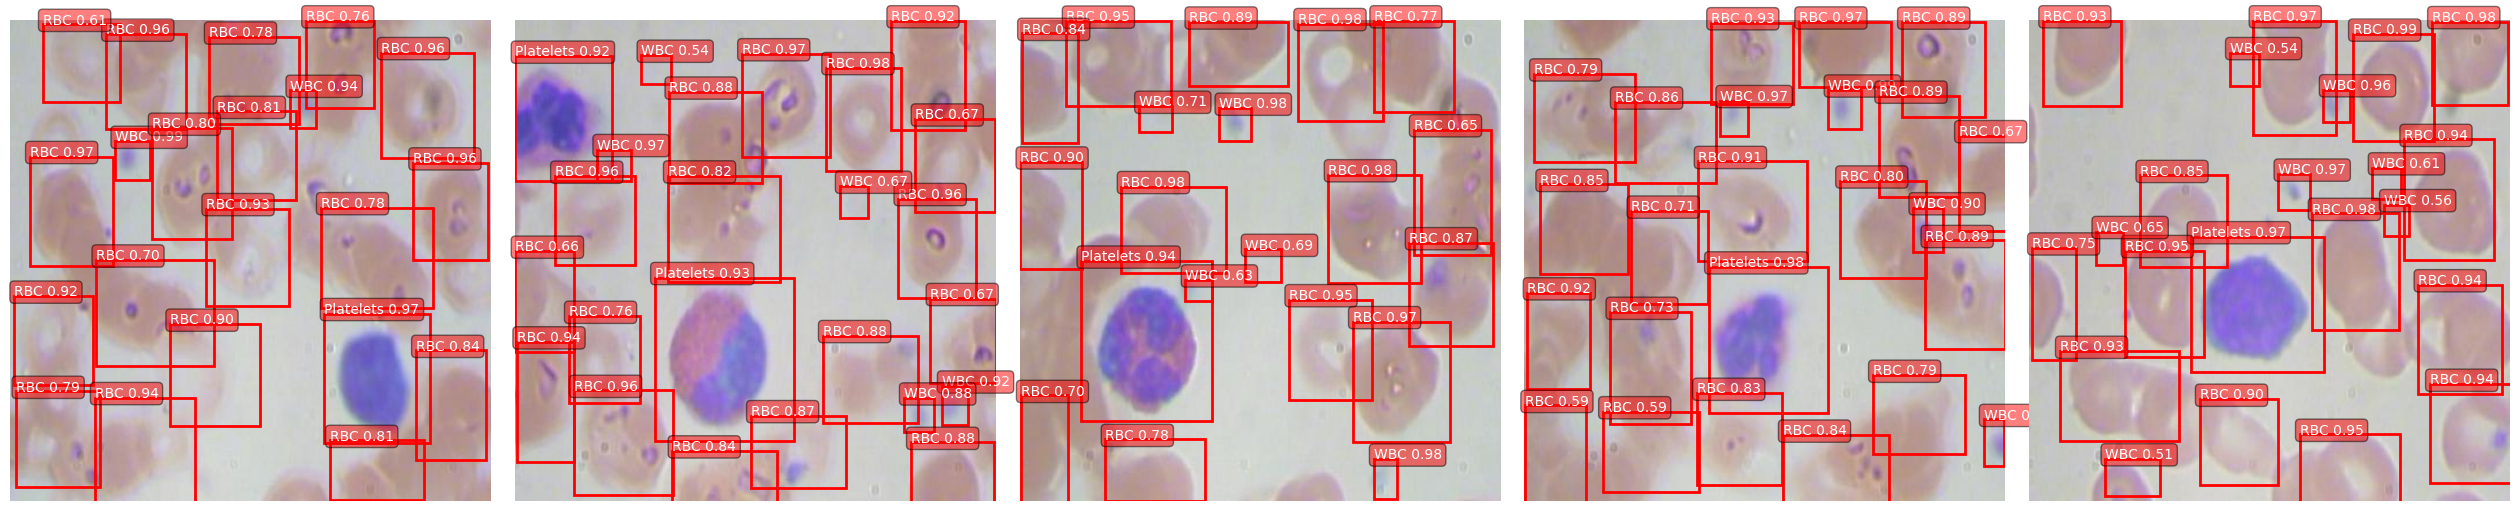

In [ ]:
import matplotlib.patches as patches

ANCHORS = anchors


GRID_SIZES = [13, 26, 52] # P5, P4, P3

INPUT_SIZE = 416



CLASSES: list[str] = [
    "WBC",  # class 0 лейкоциты
    "RBC",  # class 1 эритроциты
    "Platelets",  # class 2 тромбоциты
]

NUM_CLASSES_MODEL = 3


DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


CHECKPOINT_PATH = "checkpoint_yolov3.pth"

transform = transforms.Compose([
    transforms.Resize((416, 416)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean = [0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_samples = [test_dataset[i] for i in range(min(5, len(test_dataset)))]

print(f"\nЗапуск инференса на {len(test_samples)} изображениях...")

fig, axes = plt.subplots(1, 5, figsize=(25, 16))
if len(test_samples) == 1:
    axes = [axes]

for i, sample in enumerate(test_samples):
    img_t, target = sample
    img_path = target['path']

    ax = axes[i]
    ax.axis("off")

    original_image = Image.open(img_path).convert('RGB')
    img_tensor = transform(original_image).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        predictions = model(img_tensor)

    decoded_boxes = decode_predictions(
        predictions, ANCHORS, GRID_SIZES,
        num_classes=NUM_CLASSES_MODEL,
        input_size=INPUT_SIZE,
        conf_threshold=0.5
    )

    final_boxes_nms = nms(decoded_boxes, iou_threshold=0.1)

    if final_boxes_nms.shape[0] > 0:
        boxes_scaled = scale_boxes(
            final_boxes_nms.cpu(),
            (INPUT_SIZE, INPUT_SIZE),
            original_image.size
        )
    else:
        boxes_scaled = torch.empty(0, 6)


    ax.imshow(original_image)
    orig_width, orig_height = original_image.size
    aspect_ratio = orig_height / orig_width


    ax.set_aspect(aspect_ratio)


    plt.subplots_adjust(wspace=0, hspace=0, left=0, right=1, top=1, bottom=0)

    if boxes_scaled.shape[0] > 0:

        for box in boxes_scaled:
            x1, y1, x2, y2 = box[:4]
            label = int(box[5])
            score = box[4]


            rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                   linewidth=2, edgecolor='red', facecolor='none')
            ax.add_patch(rect)


            ax.text(x1, y1, f'{CLASSES[label]} {score:.2f}',
                   bbox=dict(boxstyle='round', facecolor='red', alpha=0.5),
                   fontsize=10, color='white')
    else:
        ax.text(0.5, 0.5, "Объекты не найдены", transform=ax.transAxes,
                horizontalalignment='center', verticalalignment='center',
                fontsize=14, bbox=dict(boxstyle='round', facecolor='red', alpha=0.5))


plt.tight_layout(pad=0)
plt.subplots_adjust(wspace=0.05, hspace=0)
plt.show()

**Выводы:**

* mAP@.50:.95 = 0.4087 \

Средняя точность по IoU порогам от 0.50 до 0.95 с шагом 0.05 (учитывает точное позиционирование) \

40.87% - хороший результат

* mAP@.50 = 0.7770 \

77.70% - тоже хорошо (т.к. IoU ≥ 0.50) \

Показывает, что модель хорошо находит объекты

* mAP@.75 = 0.3656 \
36.56% - требует очень точного позиционирования (IoU ≥ 0.75) \

можно улучшить точность bounding boxes \

* Время: 0.2639 сек/изображение, FPS: 3.79
~4 кадра в секунду - медленно....

* Визульно видим, что разные типы клеток довольно хорошо детектируются, но WBC часто детектируются на фоне (там где их нет)


**Conclusion** 

Внедрение глубокого обучения в анализ мазков крови трансформирует гематологию из субъективного искусства в точную дисциплину, основанную на данных.

Ключевые результаты проекта:

* Высокая специфичность: Модель успешно справляется с перекрывающимися объектами (слипшимися клетками), что часто является проблемой для классических алгоритмов обработки изображений.

* Оптимизация рабочего процесса: Автоматизация рутинного подсчета высвобождает время врача для анализа сложных клинических случаев.

* Универсальность: Разработанный пайплайн легко адаптируется под детекцию других биомаркеров или паразитов (например, малярийного плазмодия) при соответствующей переразметке данных.